In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/ML_assignment_4'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"it created: {PROJECT_PATH}")

%cd {PROJECT_PATH}

Mounted at /content/drive
/content/drive/MyDrive/ML_assignment_4


In [ ]:
import os

GITHUB_USERNAME = "GiorgiMzarelua"
GITHUB_TOKEN = "YOUR_TOKEN_HERE"
REPO_NAME = "ml_assignment_4"

!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git

os.chdir(REPO_NAME)

fatal: destination path 'ml_assignment_4' already exists and is not an empty directory.


In [5]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_bec17eb49054f6dbe53a546c83161e38"

!pip install kaggle --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 17.0 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [7]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

!unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d fer_dataset

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
replace fer_dataset/example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fer_dataset/example_submission.csv  
replace fer_dataset/fer2013.tar.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fer_dataset/fer2013.tar.gz  
replace fer_dataset/icml_face_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fer_dataset/icml_face_data.csv  
replace fer_dataset/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fer_dataset/test.csv    
replace fer_dataset/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fer_dataset/train.csv   


In [8]:
!pip install wandb -qU
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gmzar23 (gmzar23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [9]:
import pandas as pd
import numpy as np

# adjust if your path differs
BASE = "/content/drive/MyDrive/ML_assignment_4/ml_assignment_4/fer_dataset"
df = pd.read_csv(f"{BASE}/icml_face_data.csv")

# strip the leading spaces this file is notorious for
df.columns = [c.strip() for c in df.columns]
print("Columns:", list(df.columns))
print("Shape:", df.shape)

# canonical competition split lives in the Usage column
print("\nUsage split:")
print(df["Usage"].value_counts())

# 7 emotion classes
emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
print("\nEmotion counts:")
print(df["emotion"].value_counts().sort_index())

Columns: ['emotion', 'Usage', 'pixels']
Shape: (35887, 3)

Usage split:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

Emotion counts:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64


Image shape: (48, 48)
dtype: uint8
min / max: 11 210
Label: Angry


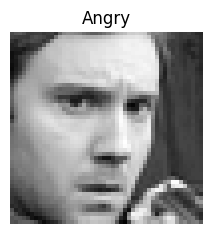

In [10]:
import matplotlib.pyplot as plt

def parse_pixels(pixel_string):
    """Space-separated string -> (48, 48) uint8 array."""
    return np.array(pixel_string.split(), dtype=np.uint8).reshape(48, 48)

# decode the very first row and inspect it
img0 = parse_pixels(df.loc[0, "pixels"])
print("Image shape:", img0.shape)        # expect (48, 48)
print("dtype:", img0.dtype)              # expect uint8
print("min / max:", img0.min(), img0.max())  # expect 0 ... 255 (or close)
print("Label:", emotion_names[df.loc[0, "emotion"]])

plt.figure(figsize=(2.5, 2.5))
plt.imshow(img0, cmap="gray")
plt.title(emotion_names[df.loc[0, "emotion"]])
plt.axis("off")
plt.show()

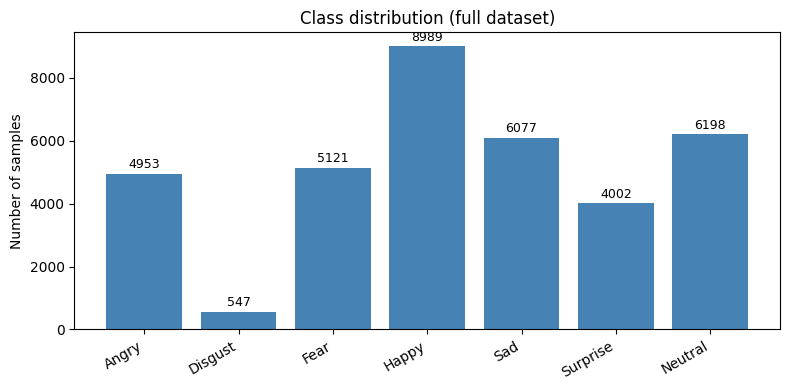

Most common : Happy (8989)
Least common: Disgust (547)
Imbalance ratio: 16.4x


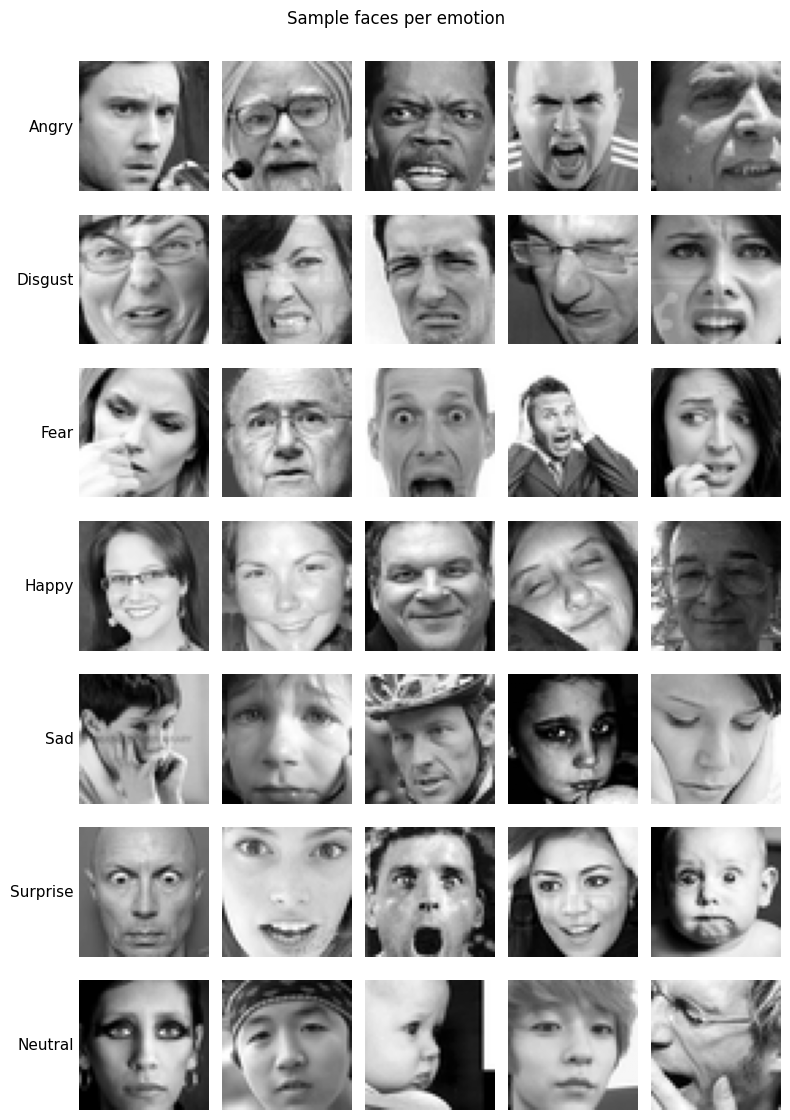

In [11]:
# --- 1. Class distribution ---
counts = df["emotion"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(emotion_names, counts.values, color="steelblue")
ax.set_title("Class distribution (full dataset)")
ax.set_ylabel("Number of samples")
ax.bar_label(bars, padding=2, fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# imbalance ratio, for the README
print(f"Most common : {emotion_names[counts.idxmax()]} ({counts.max()})")
print(f"Least common: {emotion_names[counts.idxmin()]} ({counts.min()})")
print(f"Imbalance ratio: {counts.max() / counts.min():.1f}x")

# --- 2. Sample grid: a few faces per emotion ---
N_PER_CLASS = 5
fig, axes = plt.subplots(7, N_PER_CLASS, figsize=(N_PER_CLASS * 1.6, 7 * 1.6))

for row, emo in enumerate(range(7)):
    samples = df[df["emotion"] == emo].head(N_PER_CLASS)
    for col, (_, r) in enumerate(samples.iterrows()):
        ax = axes[row, col]
        ax.imshow(parse_pixels(r["pixels"]), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(emotion_names[emo], rotation=0, ha="right",
                          va="center", fontsize=11)
            ax.axis("on")
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(False)

plt.suptitle("Sample faces per emotion", y=1.0)
plt.tight_layout()
plt.show()

In [12]:
# parse every row once -> (N, 48, 48) uint8
all_images = np.stack([parse_pixels(p) for p in df["pixels"]])
all_labels = df["emotion"].to_numpy()
usage = df["Usage"].to_numpy()

# canonical competition split
train_mask = usage == "Training"
val_mask   = usage == "PublicTest"
test_mask  = usage == "PrivateTest"

X_train, y_train = all_images[train_mask], all_labels[train_mask]
X_val,   y_val   = all_images[val_mask],   all_labels[val_mask]
X_test,  y_test  = all_images[test_mask],  all_labels[test_mask]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

# normalization stats from TRAIN ONLY, on the 0-1 scale ToTensor() will produce
train_mean = (X_train / 255.0).mean()
train_std  = (X_train / 255.0).std()
print(f"\nTrain mean: {train_mean:.4f}")
print(f"Train std : {train_std:.4f}")

Train: (28709, 48, 48)  Val: (3589, 48, 48)  Test: (3589, 48, 48)

Train mean: 0.5077
Train std : 0.2550


In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [15]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

BATCH_SIZE = 128

# eval / plain: tensor + normalize with train stats
eval_tf = transforms.Compose([
    transforms.ToTensor(),                                   # -> [1,48,48], 0..1
    transforms.Normalize(mean=[train_mean], std=[train_std]),
])

# augmented: modest, label-preserving for faces (used later)
train_tf_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std]),
])

class FERDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images          # (N, 48, 48) uint8
        self.labels = labels          # (N,) int
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# default (plain) loaders for sanity checks + baselines
train_ds = FERDataset(X_train, y_train, transform=eval_tf)
val_ds   = FERDataset(X_val,   y_val,   transform=eval_tf)
test_ds  = FERDataset(X_test,  y_test,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# one-batch sanity check
images, labels = next(iter(train_loader))
print("Batch images:", images.shape)              # [128, 1, 48, 48]
print("Batch labels:", labels.shape)              # [128]
print("dtype:", images.dtype)                     # float32
print("min/max after norm:", round(images.min().item(), 3),
      round(images.max().item(), 3))
print("Label sample:", labels[:8].tolist())

Batch images: torch.Size([128, 1, 48, 48])
Batch labels: torch.Size([128])
dtype: torch.float32
min/max after norm: -1.991 1.93
Label sample: [4, 6, 3, 0, 0, 3, 3, 2]


In [16]:
import torch.nn as nn
import torch.nn.functional as F
import math

class LogisticRegression(nn.Module):
    """Single linear layer: 48*48 -> 7. The baseline floor."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.fc = nn.Linear(48 * 48, num_classes)
    def forward(self, x):
        x = x.view(x.size(0), -1)      # flatten [B,1,48,48] -> [B,2304]
        return self.fc(x)

criterion = nn.CrossEntropyLoss()

# loss-at-init check on one batch
model = LogisticRegression().to(device)
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images)
    loss = criterion(logits, labels)

print(f"Logits shape: {logits.shape}")          # [128, 7]
print(f"Loss at init: {loss.item():.4f}")
print(f"Expected ~ln(7): {math.log(7):.4f}")

Logits shape: torch.Size([128, 7])
Loss at init: 2.0618
Expected ~ln(7): 1.9459


In [17]:
# grab one small fixed batch
tiny_images, tiny_labels = next(iter(train_loader))
tiny_images = tiny_images[:25].to(device)
tiny_labels = tiny_labels[:25].to(device)

# fresh model + optimizer
model = LogisticRegression().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Overfitting 25 samples (should reach ~100% train acc):\n")
for step in range(200):
    model.train()
    optimizer.zero_grad()
    logits = model(tiny_images)
    loss = criterion(logits, tiny_labels)
    loss.backward()
    optimizer.step()

    if (step + 1) % 25 == 0:
        preds = logits.argmax(dim=1)
        acc = (preds == tiny_labels).float().mean().item()
        print(f"  step {step+1:3d} | loss {loss.item():.4f} | acc {acc:.2%}")

Overfitting 25 samples (should reach ~100% train acc):

  step  25 | loss 0.0071 | acc 100.00%
  step  50 | loss 0.0022 | acc 100.00%
  step  75 | loss 0.0017 | acc 100.00%
  step 100 | loss 0.0014 | acc 100.00%
  step 125 | loss 0.0012 | acc 100.00%
  step 150 | loss 0.0011 | acc 100.00%
  step 175 | loss 0.0010 | acc 100.00%
  step 200 | loss 0.0009 | acc 100.00%


In [19]:
import wandb
import time

def evaluate(model, loader, criterion):
    """Returns avg loss, accuracy, and (preds, labels) over a loader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    avg_loss = total_loss / total
    acc = correct / total
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return avg_loss, acc, all_preds, all_labels


def train_model(model, config, train_loader, val_loader,
                criterion, optimizer, scheduler=None):
    """
    Generic training loop with wandb logging.
    Assumes wandb.init() was already called by the caller.
    Returns the trained model and a history dict.
    """
    model = model.to(device)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(config["epochs"]):
        # ---- train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        t0 = time.time()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- validate ----
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        if scheduler is not None:
            scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        # ---- log ----
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": current_lr,
        })

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        best_val_acc = max(best_val_acc, val_acc)

        print(f"Epoch {epoch+1:2d}/{config['epochs']} | "
              f"train_loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"val_loss {val_loss:.4f} acc {val_acc:.3f} | "
              f"{time.time()-t0:.1f}s")

    wandb.summary["best_val_acc"] = best_val_acc
    print(f"\nBest val acc: {best_val_acc:.3f}")
    return model, history

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_and_per_class(preds, labels, class_names=emotion_names,
                                 title="Confusion Matrix", log_wandb=False):
    """Row-normalized confusion matrix + per-class accuracy print."""
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row = true class

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1, ax=ax, cbar_kws={"label": "recall"})
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()

    if log_wandb:
        wandb.log({"confusion_matrix": wandb.Image(fig)})
    plt.show()

    # per-class accuracy = diagonal of row-normalized cm = recall
    print("\nPer-class accuracy (recall):")
    for i, name in enumerate(class_names):
        print(f"  {name:9s}: {cm_norm[i, i]:.3f}  (support={cm.sum(axis=1)[i]})")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch  1/10 | train_loss 1.7841 acc 0.312 | val_loss 1.6907 acc 0.356 | 5.5s
Epoch  2/10 | train_loss 1.7154 acc 0.345 | val_loss 1.7222 acc 0.346 | 7.4s
Epoch  3/10 | train_loss 1.6881 acc 0.355 | val_loss 1.6953 acc 0.356 | 5.6s
Epoch  4/10 | train_loss 1.6594 acc 0.366 | val_loss 1.7071 acc 0.354 | 6.0s
Epoch  5/10 | train_loss 1.6414 acc 0.373 | val_loss 1.7046 acc 0.351 | 6.7s
Epoch  6/10 | train_loss 1.6346 acc 0.374 | val_loss 1.7091 acc 0.357 | 5.3s
Epoch  7/10 | train_loss 1.6206 acc 0.379 | val_loss 1.7275 acc 0.344 | 7.2s
Epoch  8/10 | train_loss 1.6219 acc 0.383 | val_loss 1.7261 acc 0.343 | 5.5s
Epoch  9/10 | train_loss 1.6048 acc 0.386 | val_loss 1.7411 acc 0.344 | 6.8s
Epoch 10/10 | train_loss 1.5982 acc 0.387 | val_loss 1.7471 acc 0.325 | 6.1s

Best val acc: 0.357


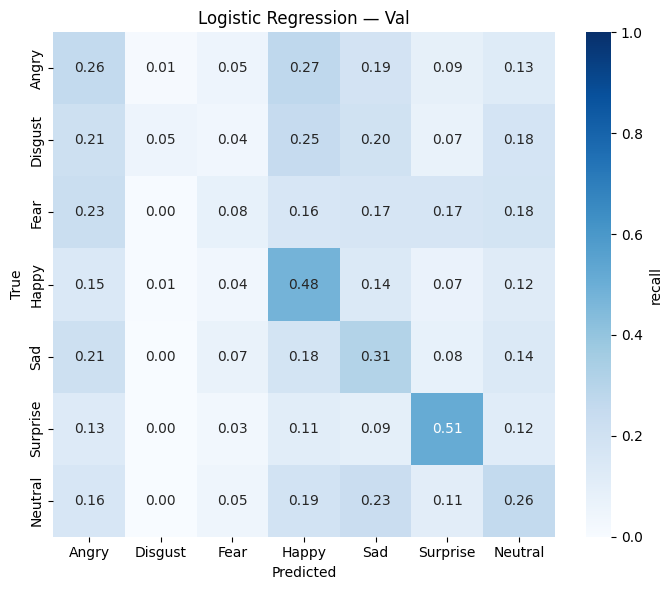


Per-class accuracy (recall):
  Angry    : 0.261  (support=467)
  Disgust  : 0.054  (support=56)
  Fear     : 0.079  (support=496)
  Happy    : 0.479  (support=895)
  Sad      : 0.311  (support=653)
  Surprise : 0.513  (support=415)
  Neutral  : 0.260  (support=607)


epoch,▁▂▃▃▄▅▆▆▇█
lr,▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▅▆▇▇▇███
train_loss,█▅▄▃▃▂▂▂▁▁
val_acc,█▆█▇▇█▅▅▅▁
val_loss,▁▅▂▃▃▃▆▅▇█
best_val_acc,0.35692
epoch,10
lr,0.001
train_acc,0.38699
train_loss,1.59819


In [21]:
config = {
    "architecture": "logistic_regression",
    "epochs": 10,
    "lr": 1e-3,
    "optimizer": "adam",
    "batch_size": BATCH_SIZE,
}

run = wandb.init(project="ML_assignment_4", name="01_logistic_regression",
                 config=config, reinit=True)

model = LogisticRegression().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

model, history = train_model(model, config, train_loader, val_loader,
                             criterion, optimizer)

val_loss, val_acc, preds, labels = evaluate(model, val_loader, criterion)
plot_confusion_and_per_class(preds, labels,
                             title="Logistic Regression — Val",
                             log_wandb=True)

wandb.finish()

Epoch  1/10 | train_loss 1.7046 acc 0.342 | val_loss 1.6098 acc 0.376 | 5.9s
Epoch  2/10 | train_loss 1.5564 acc 0.403 | val_loss 1.5538 acc 0.402 | 7.0s
Epoch  3/10 | train_loss 1.4911 acc 0.430 | val_loss 1.5529 acc 0.412 | 7.2s
Epoch  4/10 | train_loss 1.4389 acc 0.454 | val_loss 1.5583 acc 0.399 | 7.6s
Epoch  5/10 | train_loss 1.3823 acc 0.478 | val_loss 1.5847 acc 0.413 | 5.7s
Epoch  6/10 | train_loss 1.3344 acc 0.498 | val_loss 1.5812 acc 0.418 | 7.7s
Epoch  7/10 | train_loss 1.2815 acc 0.523 | val_loss 1.6102 acc 0.412 | 5.8s
Epoch  8/10 | train_loss 1.2256 acc 0.546 | val_loss 1.6333 acc 0.410 | 6.9s
Epoch  9/10 | train_loss 1.1714 acc 0.566 | val_loss 1.6216 acc 0.438 | 6.6s
Epoch 10/10 | train_loss 1.1174 acc 0.587 | val_loss 1.6633 acc 0.435 | 5.6s

Best val acc: 0.438


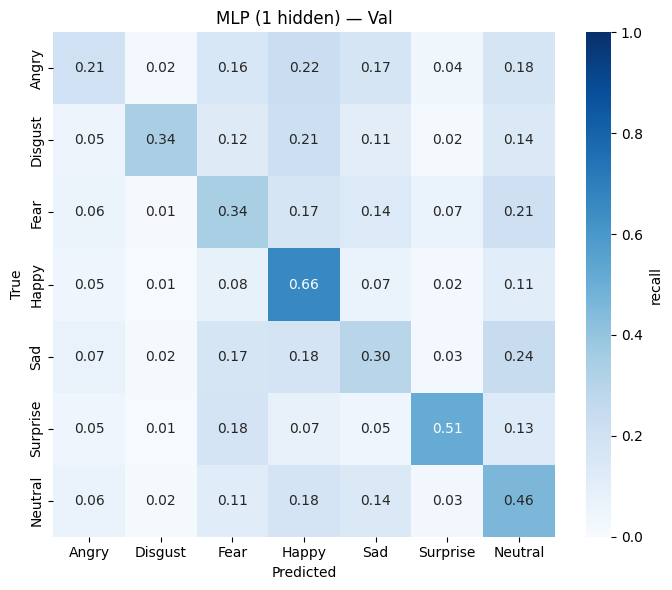


Per-class accuracy (recall):
  Angry    : 0.206  (support=467)
  Disgust  : 0.339  (support=56)
  Fear     : 0.341  (support=496)
  Happy    : 0.663  (support=895)
  Sad      : 0.296  (support=653)
  Surprise : 0.513  (support=415)
  Neutral  : 0.458  (support=607)


epoch,▁▂▃▃▄▅▆▆▇█
lr,▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▄▅▅▆▇▇█
train_loss,█▆▅▅▄▄▃▂▂▁
val_acc,▁▄▅▄▅▆▅▅██
val_loss,▅▁▁▁▃▃▅▆▅█
best_val_acc,0.43801
epoch,10
lr,0.001
train_acc,0.58703
train_loss,1.11743


In [22]:
class MLP(nn.Module):
    """One hidden layer. Adds non-linearity, still no spatial structure."""
    def __init__(self, hidden=256, num_classes=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48 * 48, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, x):
        return self.net(x)


config = {
    "architecture": "mlp_1hidden",
    "epochs": 10,
    "lr": 1e-3,
    "optimizer": "adam",
    "hidden": 256,
    "batch_size": BATCH_SIZE,
}

run = wandb.init(project="ML_assignment_4", name="02_mlp_1hidden",
                 config=config, reinit=True)

model = MLP(hidden=config["hidden"]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

model, history = train_model(model, config, train_loader, val_loader,
                             criterion, optimizer)

val_loss, val_acc, preds, labels = evaluate(model, val_loader, criterion)
plot_confusion_and_per_class(preds, labels,
                             title="MLP (1 hidden) — Val",
                             log_wandb=True)

wandb.finish()

Loss at init: 1.9589 (expect ~1.9459)

Epoch  1/10 | train_loss 1.5682 acc 0.390 | val_loss 1.4192 acc 0.458 | 8.0s
Epoch  2/10 | train_loss 1.3340 acc 0.494 | val_loss 1.3364 acc 0.482 | 6.0s
Epoch  3/10 | train_loss 1.2152 acc 0.540 | val_loss 1.2717 acc 0.517 | 7.8s
Epoch  4/10 | train_loss 1.1126 acc 0.584 | val_loss 1.2464 acc 0.526 | 6.0s
Epoch  5/10 | train_loss 0.9973 acc 0.628 | val_loss 1.3044 acc 0.524 | 6.9s
Epoch  6/10 | train_loss 0.8855 acc 0.674 | val_loss 1.2868 acc 0.534 | 6.7s
Epoch  7/10 | train_loss 0.7532 acc 0.728 | val_loss 1.3744 acc 0.529 | 6.4s
Epoch  8/10 | train_loss 0.6264 acc 0.776 | val_loss 1.4340 acc 0.541 | 7.4s
Epoch  9/10 | train_loss 0.4931 acc 0.832 | val_loss 1.6182 acc 0.541 | 5.9s
Epoch 10/10 | train_loss 0.3738 acc 0.874 | val_loss 1.8195 acc 0.530 | 7.9s

Best val acc: 0.541


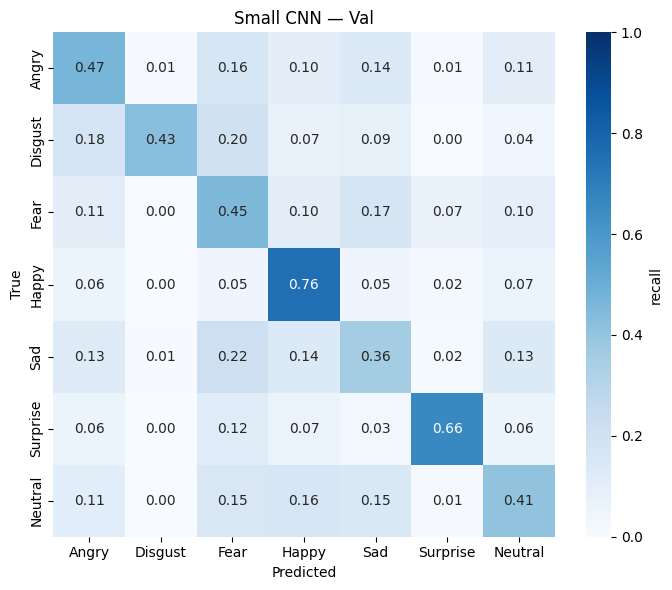


Per-class accuracy (recall):
  Angry    : 0.471  (support=467)
  Disgust  : 0.429  (support=56)
  Fear     : 0.452  (support=496)
  Happy    : 0.758  (support=895)
  Sad      : 0.358  (support=653)
  Surprise : 0.663  (support=415)
  Neutral  : 0.409  (support=607)


epoch,▁▂▃▃▄▅▆▆▇█
lr,▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▃▄▄▅▆▇▇█
train_loss,█▇▆▅▅▄▃▂▂▁
val_acc,▁▃▆▇▇▇▇██▇
val_loss,▃▂▁▁▂▁▃▃▆█
best_val_acc,0.5411
epoch,10
lr,0.001
train_acc,0.87412
train_loss,0.37382


In [23]:
class SmallCNN(nn.Module):
    """2 conv blocks, then a small classifier head. Keeps spatial structure."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 24x24

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 12x12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 128),                 # 9216 -> 128
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


config = {
    "architecture": "small_cnn_2block",
    "epochs": 10,
    "lr": 1e-3,
    "optimizer": "adam",
    "batch_size": BATCH_SIZE,
}

run = wandb.init(project="ML_assignment_4", name="03_small_cnn",
                 config=config, reinit=True)

model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

# quick loss-at-init check — confirms the 9216 flatten dim is wired right
images, labels = next(iter(train_loader))
with torch.no_grad():
    init_loss = criterion(model(images.to(device)), labels.to(device))
print(f"Loss at init: {init_loss.item():.4f} (expect ~{math.log(7):.4f})\n")

model, history = train_model(model, config, train_loader, val_loader,
                             criterion, optimizer)

val_loss, val_acc, preds, labels = evaluate(model, val_loader, criterion)
plot_confusion_and_per_class(preds, labels,
                             title="Small CNN — Val", log_wandb=True)

wandb.finish()

Loss at init: 2.0453 (expect ~1.9459)

Epoch  1/15 | train_loss 1.6418 acc 0.367 | val_loss 1.4048 acc 0.461 | 6.2s
Epoch  2/15 | train_loss 1.3161 acc 0.492 | val_loss 1.4926 acc 0.409 | 7.9s
Epoch  3/15 | train_loss 1.1888 acc 0.549 | val_loss 1.2244 acc 0.532 | 6.3s
Epoch  4/15 | train_loss 1.0989 acc 0.585 | val_loss 1.2181 acc 0.540 | 7.8s
Epoch  5/15 | train_loss 1.0195 acc 0.614 | val_loss 1.2127 acc 0.546 | 6.7s
Epoch  6/15 | train_loss 0.9399 acc 0.648 | val_loss 1.1811 acc 0.555 | 7.0s
Epoch  7/15 | train_loss 0.8667 acc 0.675 | val_loss 1.1985 acc 0.563 | 7.4s
Epoch  8/15 | train_loss 0.7963 acc 0.705 | val_loss 1.3119 acc 0.541 | 6.8s
Epoch  9/15 | train_loss 0.7167 acc 0.731 | val_loss 1.2435 acc 0.582 | 7.9s
Epoch 10/15 | train_loss 0.6169 acc 0.774 | val_loss 1.2415 acc 0.585 | 6.6s
Epoch 11/15 | train_loss 0.5365 acc 0.804 | val_loss 1.3031 acc 0.586 | 7.9s
Epoch 12/15 | train_loss 0.4385 acc 0.845 | val_loss 1.5590 acc 0.573 | 6.4s
Epoch 13/15 | train_loss 0.3828 acc 0

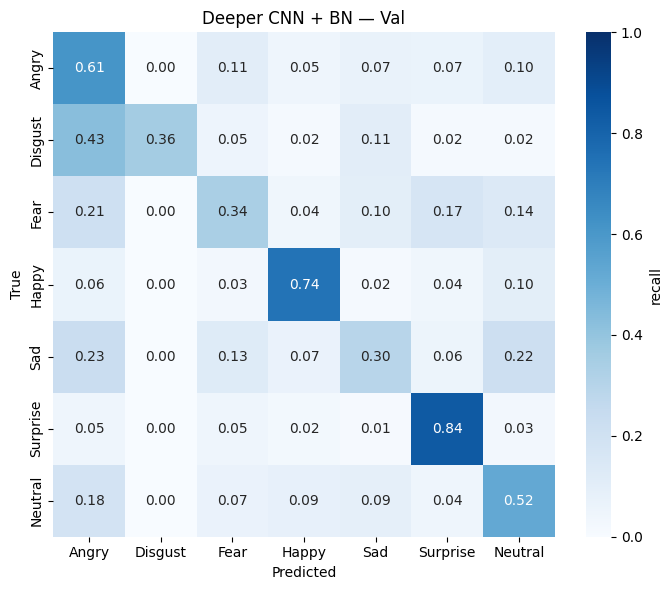


Per-class accuracy (recall):
  Angry    : 0.610  (support=467)
  Disgust  : 0.357  (support=56)
  Fear     : 0.337  (support=496)
  Happy    : 0.742  (support=895)
  Sad      : 0.296  (support=653)
  Surprise : 0.839  (support=415)
  Neutral  : 0.524  (support=607)


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▃▄▄▅▅▅▆▆▇▇▇██
train_loss,█▆▆▅▅▄▄▄▃▃▂▂▂▁▁
val_acc,▃▁▆▆▆▇▇▆███▇▆█▇
val_loss,▃▄▁▁▁▁▁▂▂▂▂▅▇▆█
best_val_acc,0.59348
epoch,15
lr,0.001
train_acc,0.91623
train_loss,0.24849


In [24]:
class DeeperCNN(nn.Module):
    """3 conv blocks with BatchNorm. More capacity, better-conditioned."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 24x24

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 12x12

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 6x6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256), nn.ReLU(),           # 4608 -> 256
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


config = {
    "architecture": "deeper_cnn_bn_3block",
    "epochs": 15,
    "lr": 1e-3,
    "optimizer": "adam",
    "batch_size": BATCH_SIZE,
}

run = wandb.init(project="ML_assignment_4", name="04_deeper_cnn_bn",
                 config=config, reinit=True)

model = DeeperCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

images, labels = next(iter(train_loader))
with torch.no_grad():
    init_loss = criterion(model(images.to(device)), labels.to(device))
print(f"Loss at init: {init_loss.item():.4f} (expect ~{math.log(7):.4f})\n")

model, history = train_model(model, config, train_loader, val_loader,
                             criterion, optimizer)

val_loss, val_acc, preds, labels = evaluate(model, val_loader, criterion)
plot_confusion_and_per_class(preds, labels,
                             title="Deeper CNN + BN — Val", log_wandb=True)

wandb.finish()

Loss at init: 1.9609 (expect ~1.9459)

Epoch  1/30 | train_loss 1.8055 acc 0.261 | val_loss 1.6335 acc 0.331 | 11.5s
Epoch  2/30 | train_loss 1.6557 acc 0.340 | val_loss 1.5037 acc 0.413 | 11.6s
Epoch  3/30 | train_loss 1.5836 acc 0.378 | val_loss 1.4508 acc 0.451 | 9.5s
Epoch  4/30 | train_loss 1.5343 acc 0.401 | val_loss 1.4016 acc 0.473 | 11.2s
Epoch  5/30 | train_loss 1.4996 acc 0.419 | val_loss 1.3427 acc 0.489 | 11.5s
Epoch  6/30 | train_loss 1.4824 acc 0.422 | val_loss 1.3291 acc 0.490 | 10.7s
Epoch  7/30 | train_loss 1.4616 acc 0.433 | val_loss 1.3064 acc 0.503 | 10.5s
Epoch  8/30 | train_loss 1.4513 acc 0.434 | val_loss 1.2859 acc 0.503 | 11.6s
Epoch  9/30 | train_loss 1.4323 acc 0.442 | val_loss 1.2872 acc 0.500 | 11.4s
Epoch 10/30 | train_loss 1.4233 acc 0.448 | val_loss 1.2855 acc 0.502 | 9.4s
Epoch 11/30 | train_loss 1.4116 acc 0.450 | val_loss 1.2683 acc 0.509 | 11.5s
Epoch 12/30 | train_loss 1.3918 acc 0.458 | val_loss 1.3025 acc 0.497 | 11.7s
Epoch 13/30 | train_loss 1.

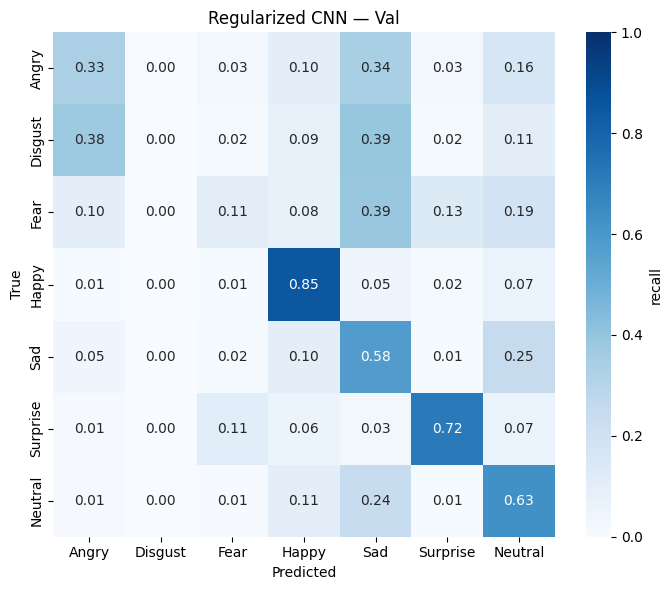


Per-class accuracy (recall):
  Angry    : 0.334  (support=467)
  Disgust  : 0.000  (support=56)
  Fear     : 0.107  (support=496)
  Happy    : 0.851  (support=895)
  Sad      : 0.579  (support=653)
  Surprise : 0.718  (support=415)
  Neutral  : 0.626  (support=607)


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████
train_loss,█▆▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇███████
val_loss,█▆▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
best_val_acc,0.56562
epoch,30
lr,0.001
train_acc,0.51472
train_loss,1.26839


In [25]:
class RegularizedCNN(nn.Module):
    """Same 3-block backbone as DeeperCNN, plus dropout. Trained with
    augmentation + weight decay. The regularized counterpart."""
    def __init__(self, num_classes=7, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 24x24

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 12x12

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 6x6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(128 * 6 * 6, 256), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


# augmented train loader — ONLY for this run. val/test stay plain.
train_ds_aug = FERDataset(X_train, y_train, transform=train_tf_aug)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)

config = {
    "architecture": "regularized_cnn",
    "epochs": 30,
    "lr": 1e-3,
    "optimizer": "adamw",
    "weight_decay": 1e-4,
    "dropout_p": 0.5,
    "augmentation": True,
    "batch_size": BATCH_SIZE,
}

run = wandb.init(project="ML_assignment_4", name="05_regularized_cnn",
                 config=config, reinit=True)

model = RegularizedCNN(dropout_p=config["dropout_p"]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"],
                              weight_decay=config["weight_decay"])

images, labels = next(iter(train_loader_aug))
with torch.no_grad():
    init_loss = criterion(model(images.to(device)), labels.to(device))
print(f"Loss at init: {init_loss.item():.4f} (expect ~{math.log(7):.4f})\n")

model, history = train_model(model, config, train_loader_aug, val_loader,
                             criterion, optimizer)

val_loss, val_acc, preds, labels = evaluate(model, val_loader, criterion)
plot_confusion_and_per_class(preds, labels,
                             title="Regularized CNN — Val", log_wandb=True)

wandb.finish()

Class counts : [3995, 436, 4097, 7215, 4830, 3171, 4965]
Class weights: [1.03, 9.41, 1.0, 0.57, 0.85, 1.29, 0.83]


Epoch  1/30 | train_loss 1.9572 acc 0.163 | val_loss 1.8772 acc 0.254 | 11.4s
Epoch  2/30 | train_loss 1.8828 acc 0.201 | val_loss 1.8643 acc 0.274 | 10.6s
Epoch  3/30 | train_loss 1.8420 acc 0.223 | val_loss 1.7298 acc 0.341 | 9.6s
Epoch  4/30 | train_loss 1.8215 acc 0.229 | val_loss 1.8204 acc 0.319 | 11.2s
Epoch  5/30 | train_loss 1.7975 acc 0.261 | val_loss 1.6225 acc 0.352 | 11.2s
Epoch  6/30 | train_loss 1.7818 acc 0.271 | val_loss 1.6649 acc 0.357 | 9.4s
Epoch  7/30 | train_loss 1.7635 acc 0.289 | val_loss 1.6476 acc 0.349 | 11.6s
Epoch  8/30 | train_loss 1.7678 acc 0.293 | val_loss 1.5739 acc 0.368 | 12.9s
Epoch  9/30 | train_loss 1.7449 acc 0.299 | val_loss 1.6153 acc 0.421 | 11.0s
Epoch 10/30 | train_loss 1.7393 acc 0.307 | val_loss 1.5668 acc 0.412 | 9.8s
Epoch 11/30 | train_loss 1.7314 acc 0.308 | val_loss 1.5672 acc 0.404 | 11.4s
Epoch 12/30 | train_loss 1.7164 acc 0.314 | val_loss 1.5704 acc 0.389 | 11.3s
Epoch 13/30 | train_loss 1.7182 acc 0.318 | val_loss 1.5632 acc 0.3

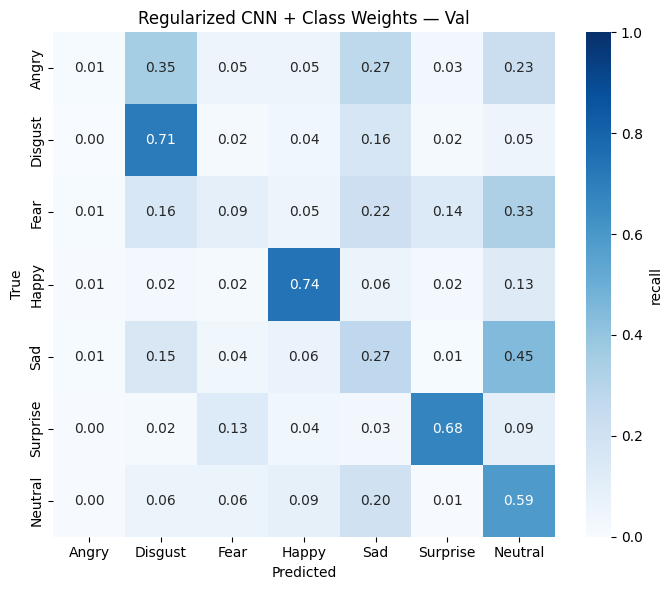


Per-class accuracy (recall):
  Angry    : 0.009  (support=467)
  Disgust  : 0.714  (support=56)
  Fear     : 0.095  (support=496)
  Happy    : 0.742  (support=895)
  Sad      : 0.273  (support=653)
  Surprise : 0.680  (support=415)
  Neutral  : 0.588  (support=607)


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▃▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████
train_loss,█▆▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▂▄▃▄▄▄▅▇▆▆▆▆▇▇▇▇█▇▇▇█▇██▇██▇▇
val_loss,██▆▇▄▅▄▃▄▃▃▃▃▃▂▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁
best_val_acc,0.46057
epoch,30
lr,0.001
train_acc,0.3517
train_loss,1.62717


In [26]:
# inverse-frequency class weights from TRAIN labels
class_counts = np.bincount(y_train, minlength=7)
class_weights = class_counts.sum() / (7 * class_counts)   # normalized inverse freq
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts :", class_counts.tolist())
print("Class weights:", [round(w, 2) for w in class_weights.tolist()])

weighted_criterion = nn.CrossEntropyLoss(weight=class_weights)

config = {
    "architecture": "regularized_cnn_weighted",
    "epochs": 30,
    "lr": 1e-3,
    "optimizer": "adamw",
    "weight_decay": 1e-4,
    "dropout_p": 0.5,
    "augmentation": True,
    "class_weighted_loss": True,
    "batch_size": BATCH_SIZE,
}

run = wandb.init(project="ML_assignment_4", name="06_regularized_cnn_weighted",
                 config=config, reinit=True)

model = RegularizedCNN(dropout_p=config["dropout_p"]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"],
                              weight_decay=config["weight_decay"])

# train with the WEIGHTED loss; evaluate with plain loss for comparability
model, history = train_model(model, config, train_loader_aug, val_loader,
                             weighted_criterion, optimizer)

val_loss, val_acc, preds, labels = evaluate(model, val_loader, criterion)
plot_confusion_and_per_class(preds, labels,
                             title="Regularized CNN + Class Weights — Val",
                             log_wandb=True)

wandb.finish()

Epoch  1/30 | train_loss 1.8495 acc 0.247 | val_loss 1.7350 acc 0.292 | 11.1s
Epoch  2/30 | train_loss 1.7131 acc 0.301 | val_loss 1.5771 acc 0.377 | 11.3s
Epoch  3/30 | train_loss 1.6266 acc 0.347 | val_loss 1.4939 acc 0.429 | 9.2s
Epoch  4/30 | train_loss 1.5842 acc 0.370 | val_loss 1.4722 acc 0.451 | 11.2s
Epoch  5/30 | train_loss 1.5535 acc 0.390 | val_loss 1.4096 acc 0.462 | 11.8s
Epoch  6/30 | train_loss 1.5211 acc 0.398 | val_loss 1.3865 acc 0.464 | 10.9s
Epoch  7/30 | train_loss 1.5072 acc 0.409 | val_loss 1.3787 acc 0.465 | 10.0s
Epoch  8/30 | train_loss 1.4957 acc 0.412 | val_loss 1.3745 acc 0.464 | 11.2s
Epoch  9/30 | train_loss 1.4769 acc 0.418 | val_loss 1.3090 acc 0.490 | 11.2s
Epoch 10/30 | train_loss 1.4604 acc 0.422 | val_loss 1.2887 acc 0.501 | 9.3s
Epoch 11/30 | train_loss 1.4546 acc 0.428 | val_loss 1.2873 acc 0.502 | 11.3s
Epoch 12/30 | train_loss 1.4433 acc 0.437 | val_loss 1.2769 acc 0.513 | 11.2s
Epoch 13/30 | train_loss 1.4271 acc 0.439 | val_loss 1.2723 acc 0.

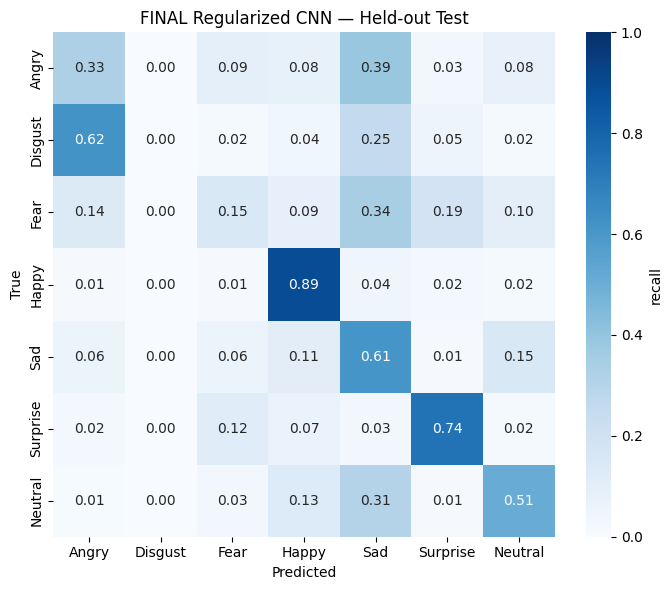


Per-class accuracy (recall):
  Angry    : 0.332  (support=491)
  Disgust  : 0.000  (support=55)
  Fear     : 0.150  (support=528)
  Happy    : 0.893  (support=879)
  Sad      : 0.613  (support=594)
  Surprise : 0.743  (support=416)
  Neutral  : 0.508  (support=626)


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▃▅▅▅▆▆▅▆▆▇▇▇▇▇▇▇▇▇▇█▇▇▇██▇███
val_loss,█▆▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▁▁▁
best_val_acc,0.55977
epoch,30
lr,0.001
test_acc,0.56227
test_loss,1.14302


In [27]:
# Final model = the regularized CNN (model #5): best honest generalization.
# Retrain a clean instance, then evaluate ONCE on the held-out PrivateTest set.

final_config = {
    "architecture": "regularized_cnn_FINAL",
    "epochs": 30,
    "lr": 1e-3,
    "optimizer": "adamw",
    "weight_decay": 1e-4,
    "dropout_p": 0.5,
    "augmentation": True,
    "batch_size": BATCH_SIZE,
}

run = wandb.init(project="ML_assignment_4", name="07_final_model_test_eval",
                 config=final_config, reinit=True)

final_model = RegularizedCNN(dropout_p=final_config["dropout_p"]).to(device)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_config["lr"],
                              weight_decay=final_config["weight_decay"])

final_model, _ = train_model(final_model, final_config, train_loader_aug,
                             val_loader, criterion, optimizer)

# the one unbiased number: held-out test set, evaluated once
test_loss, test_acc, test_preds, test_labels = evaluate(
    final_model, test_loader, criterion)

print(f"\n{'='*40}")
print(f"FINAL HELD-OUT TEST ACCURACY: {test_acc:.4f}")
print(f"Final test loss: {test_loss:.4f}")
print(f"{'='*40}")

wandb.summary["test_acc"] = test_acc
wandb.summary["test_loss"] = test_loss

plot_confusion_and_per_class(test_preds, test_labels,
                             title="FINAL Regularized CNN — Held-out Test",
                             log_wandb=True)

wandb.finish()